# Практичне завдання №1
## Лінійна регресія, оптимізація та статистичний аналіз

**Виконала:** Цюрпіта Діана  
**Група:** ФЕІ-44

## 1. Дослідження даних (EDA), відбір ознак і попередня обробка

використовується Ames Housing Dataset. 
Цільова змінна є `SalePrice` — ціна продажу будинку.
Спочатку проведим первинний аналіз даних: переглядаю структуру датасету, типи ознак, пропущені значення та основні статистичні характеристики.

In [1]:
# Імпорт бібліотеки які буду використовувати для роботи з даними
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

print("Бібліотеки завантажені")

Бібліотеки завантажені


In [2]:
# Завантажує Ames Housing Dataset
ames = fetch_openml(name="house_prices", as_frame=True)

# Об'єдную ознаки і цільову змінну в один 
df = ames.data.copy()
df["SalePrice"] = ames.target

print("Датасет  завантажено")
print("Кількість рядків:", df.shape[0])
print("Кількість стовпців:", df.shape[1])

Датасет  завантажено
Кількість рядків: 1460
Кількість стовпців: 81


In [3]:
# Перегляд перших 5 рядків датасету
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# структура датасету та типи ознак
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
# Визначення кількості пропущених значень у кожному стовпці
missing_values = df.isnull().sum()

# Залишаю тільки стовпці в яких є пропуски
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Кількість стовпців з пропущеними значеннями:", len(missing_values))
missing_values

Кількість стовпців з пропущеними значеннями: 19


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageCond        81
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrType         8
MasVnrArea         8
Electrical         1
dtype: int64

In [6]:
# Перегляд основної статистичної характеристики числових ознак
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


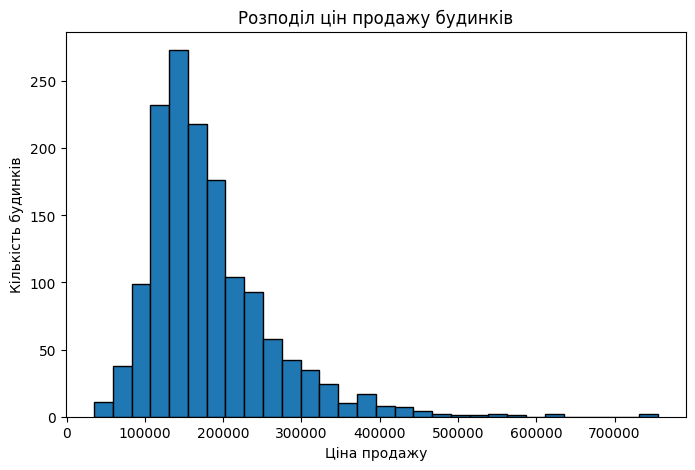

In [7]:
# гістограма розподілу цільової змінної 
plt.figure(figsize=(8, 5))
plt.hist(df["SalePrice"], bins=30, edgecolor="black")
plt.title("Розподіл цін продажу будинків")
plt.xlabel("Ціна продажу")
plt.ylabel("Кількість будинків")
plt.show()

### Висновок 1 аналізу
Датасет має 1460 записів і 81 стовпців. В ознаках є як числові так і категоріальні дані. У 19 стовпцях є пропущені значення.
Середня ціна продажу будинку = +- 180 921, а медіана 163 000. Розподіл `SalePrice` має правосторонню асиметрію: більшість будинків мають середню ціну, але і є невелика кількість дорожчих будинків.

### Відбір ознак та аналіз кореляцій

Для вибору найбільш інформативних числових ознак проаналізую їхню кореляцію з цільовою змінною `SalePrice`.

In [8]:
# Вибирає тільки числові ознаки
numeric_df = df.select_dtypes(include=np.number)

# Обчислюю кореляцію числових ознак із
correlation_with_price = (
    numeric_df.corr()["SalePrice"]
    .drop("SalePrice")
    .sort_values(ascending=False)
)

correlation_with_price

OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

### Розбиття даних на Train, Validation та Test

Перед відбором ознак і попередньою обробкою розділяю дані на навчальну, валідаційну та тестову вибірки. Потрібно для того, щоб інформація з Validation і Test не впливала на навчання і вибір ознак моделі.

In [9]:
# Імпорт функції для розбиття даних
from sklearn.model_selection import train_test_split

# Відокремлюю ознаки від цільової змінної
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# Спочатку виділила 70% даних для Train
# потім 30% буде поділена між Validation і Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

# Ділимю іншні дані порівну: 15% Validation і 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1022, 80) (1022,)
Validation: (219, 80) (219,)
Test: (219, 80) (219,)


#### Чому дані розділяються до попередньої обробки?

Дані треба! розділити на Train, Validation і Test до масштабування, кодування та відбору ознак. Щоб інформація з Validation і Test не потрапила в процес навчання моделі.
**Data Leakage** — це ситуація коли під час навчання модель отримує інформацію з даних, які повинні використовуватися тільки для її перевірки. Тому і результати моделі можуть виглядати кращими, ніж вони є насправді
Тому всі параметри попередньої обробки визначаються тільки на Train, а потім застосовуються до Validation і Test.

In [10]:
# Створено навчальний датафрейм разом з цільовою змінною
train_df = X_train.copy()
train_df["SalePrice"] = y_train

# Вибирає тільки числові ознаки
numeric_train = train_df.select_dtypes(include=np.number)

# Обчислюється кореляція числових ознак із SalePrice тільки на Train
train_correlation = (
    numeric_train.corr()["SalePrice"]
    .drop("SalePrice")
    .sort_values(ascending=False)
)

train_correlation

OverallQual      0.784720
GrLivArea        0.689238
GarageCars       0.642689
GarageArea       0.621937
TotalBsmtSF      0.590017
1stFlrSF         0.583132
FullBath         0.549164
TotRmsAbvGrd     0.519634
YearBuilt        0.512206
YearRemodAdd     0.512190
GarageYrBlt      0.474363
Fireplaces       0.461329
MasVnrArea       0.454514
BsmtFinSF1       0.360559
LotFrontage      0.340251
WoodDeckSF       0.331151
2ndFlrSF         0.314904
HalfBath         0.278889
OpenPorchSF      0.277547
LotArea          0.262896
BsmtFullBath     0.228331
BsmtUnfSF        0.223321
BedroomAbvGr     0.159879
PoolArea         0.138324
ScreenPorch      0.119974
3SsnPorch        0.059417
MoSold           0.048494
LowQualFinSF    -0.002201
BsmtFinSF2      -0.009665
YrSold          -0.012761
MiscVal         -0.016525
Id              -0.034812
BsmtHalfBath    -0.052806
OverallCond     -0.071461
MSSubClass      -0.094099
KitchenAbvGr    -0.146972
EnclosedPorch   -0.147502
Name: SalePrice, dtype: float64

In [11]:
# Вибрала числові ознаки з більшою кореляцією з SalePrice
selected_numeric = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd"
]

# Обчислюється кореляція між вибраними ознаками тільки на Train
feature_corr = X_train[selected_numeric].corr()

feature_corr.round(2)

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd
OverallQual,1.00,0.58,0.59,0.55,0.54,0.47,0.53,0.42,0.56,0.55
GrLivArea,0.58,1.00,0.46,0.48,0.45,0.56,0.62,0.82,0.16,0.28
GarageCars,0.59,0.46,1.00,0.88,0.44,0.43,0.47,0.35,0.51,0.42
GarageArea,0.55,0.48,0.88,1.00,0.49,0.49,0.42,0.34,0.46,0.37
TotalBsmtSF,0.54,0.45,0.44,0.49,1.00,0.83,0.31,0.28,0.39,0.29
1stFlrSF,0.47,0.56,0.43,0.49,0.83,1.00,0.36,0.40,0.27,0.24
FullBath,0.53,0.62,0.47,0.42,0.31,0.36,1.00,0.55,0.46,0.45
TotRmsAbvGrd,0.42,0.82,0.35,0.34,0.28,0.40,0.55,1.00,0.06,0.18
YearBuilt,0.56,0.16,0.51,0.46,0.39,0.27,0.46,0.06,1.00,0.60
YearRemodAdd,0.55,0.28,0.42,0.37,0.29,0.24,0.45,0.18,0.60,1.00


#### Аналіз кореляцій між ознаками

У вибраних числових ознак є декілька пар із сильною кореляцією. `GarageCars` і `GarageArea` мають кореляцію 0.88, `TotalBsmtSF` і `1stFlrSF` — 0.83, а `GrLivArea` і `TotRmsAbvGrd` — 0.82.
для зменшення можливої мультиколінеарності, з кожної такої пари залишаю ознаку, яка має сильніший зв'язок із `SalePrice`. Тому залишила `GarageCars`, `TotalBsmtSF` і `GrLivArea`.

In [12]:
# Точно вибрані числові ознаки
final_numeric_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt",
    "YearRemodAdd"
]

print("Вибрані числові ознаки:")
for feature in final_numeric_features:
    print("-", feature)

Вибрані числові ознаки:
- OverallQual
- GrLivArea
- GarageCars
- TotalBsmtSF
- FullBath
- YearBuilt
- YearRemodAdd


In [13]:
# Вибирає категоріальні ознаки з навчальної вибірки
categorical_features = X_train.select_dtypes(include="object").columns

print("Кількість категоріальних ознак:", len(categorical_features))

# Перегляд кількості унікальних значень у кожній категоріальній ознаці
X_train[categorical_features].nunique().sort_values()

Кількість категоріальних ознак: 43


Street            2
Alley             2
Utilities         2
CentralAir        2
LandSlope         3
PoolQC            3
PavedDrive        3
GarageFinish      3
BsmtQual          4
Electrical        4
KitchenQual       4
BsmtExposure      4
ExterQual         4
LandContour       4
MasVnrType        4
LotShape          4
Fence             4
BsmtCond          4
MiscFeature       4
BldgType          5
ExterCond         5
HeatingQC         5
MSZoning          5
LotConfig         5
GarageQual        5
GarageCond        5
FireplaceQu       5
Heating           6
BsmtFinType1      6
RoofStyle         6
Condition2        6
Foundation        6
GarageType        6
SaleCondition     6
BsmtFinType2      6
RoofMatl          7
Functional        7
HouseStyle        8
SaleType          9
Condition1        9
Exterior1st      14
Exterior2nd      16
Neighborhood     25
dtype: int64

In [14]:
# Вибір категоріальної ознаки для моделі
final_categorical_features = [
    "Neighborhood",
    "BldgType",
    "HouseStyle",
    "KitchenQual"
]

print("Вибрані категоріальні ознаки:")
for feature in final_categorical_features:
    print("-", feature)

Вибрані категоріальні ознаки:
- Neighborhood
- BldgType
- HouseStyle
- KitchenQual


#### Вибір категоріальних ознак
Для моделі вибрана `Neighborhood`, `BldgType`, `HouseStyle` та `KitchenQual`. Ці ознаки описують район, тип будинку, його стиль та якість кухні, тому можуть впливати на ціну продажу Для кодування використаю **One-Hot Encoding**, оскільки категорії не треба представляти звичайними числами, які могли б створити штучний порядок між ними Кодування буде навчатися тільки на Train. Якщо у Validation або Test зустрінеться нова категорія, якої не було в Train, вона буде ігноруватися, шоб модель могла коректно працювати з такими даними.

In [15]:
# Об'єднала вибрані числові та категоріальні ознаки
final_features = final_numeric_features + final_categorical_features

# Перевірила пропущені значення в вибраних ознаках тільки на Train
X_train[final_features].isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
FullBath        0
YearBuilt       0
YearRemodAdd    0
Neighborhood    0
BldgType        0
HouseStyle      0
KitchenQual     0
dtype: int64

### Попередня обробка даних

Вибраних ознаках пропущених значень немає, тому їх додаткове заповнення не треба. Числові ознаки буду стандартизувати за допомогою `StandardScaler`, а категоріальні кодувати методом `One-Hot Encoding`.
Всі параметри обробки визначаються тільки на Train, після чого така сама обробка застосовується до Validation і Test. Це дозволяє уникнути Data Leakage.

In [16]:
# Імпортувала для масштабування числових ознак
from sklearn.preprocessing import StandardScaler

# створила об'єкт для масштабування
scaler = StandardScaler()

# вчим scaler тільки на Train та масштабуємо Train
X_train_numeric = scaler.fit_transform(
    X_train[final_numeric_features]
)

# Для Validation і Test використала параметри, отримані на Train
X_val_numeric = scaler.transform(
    X_val[final_numeric_features]
)

X_test_numeric = scaler.transform(
    X_test[final_numeric_features]
)

print("Train:", X_train_numeric.shape)
print("Validation:", X_val_numeric.shape)
print("Test:", X_test_numeric.shape)

Train: (1022, 7)
Validation: (219, 7)
Test: (219, 7)


In [17]:
# Імпорт для кодування категоріальних ознак
from sklearn.preprocessing import OneHotEncoder

# Створенп encoder
# handle_unknown="ignore" дозволяє коректно обробляти нові категорії
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# вчу encoder тільки на Train
X_train_categorical = encoder.fit_transform(
    X_train[final_categorical_features]
)

# Для Validation і Test використала вже навчений encoder
X_val_categorical = encoder.transform(
    X_val[final_categorical_features]
)

X_test_categorical = encoder.transform(
    X_test[final_categorical_features]
)

print("Train:", X_train_categorical.shape)
print("Validation:", X_val_categorical.shape)
print("Test:", X_test_categorical.shape)

Train: (1022, 42)
Validation: (219, 42)
Test: (219, 42)


In [18]:
# Об'єднання числові та категоріальні ознаки
X_train_processed = np.hstack([
    X_train_numeric,
    X_train_categorical
])

X_val_processed = np.hstack([
    X_val_numeric,
    X_val_categorical
])

X_test_processed = np.hstack([
    X_test_numeric,
    X_test_categorical
])

print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

Train: (1022, 49)
Validation: (219, 49)
Test: (219, 49)


## 2. Реалізація лінійної регресії засобами NumPy

Лінійна регресія використовується для прогнозування числового значення на основі набору ознак.
Модель має вигляд:
$$
\hat{y} = Xw + b
$$
де:
- $X$ — матриця ознак;
- $w$ — ваги моделі;
- $b$ — зміщення;
- $\hat{y}$ — прогнозоване значення.
Для оцінки помилки будемо використовувати середньоквадратичну помилку (MSE):
$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$
Параметри $w$ і $b$ будемо оновлювати за допомогою градієнтного спуску.

In [19]:
# Функція обчислення прогнозу лінійної регресії
def predict(X, w, b):
    return X @ w + b

In [20]:
# Функція  обчислення середньоквадратичної помилки
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [21]:
# Функція  обчислення градієнтів ваг і зміщення
def compute_gradients(X, y, w, b):
    n = len(y)

    # Обчислення прогноз
    y_pred = predict(X, w, b)

    # Обчислення різницю між прогнозом і правильними значеннями
    error = y_pred - y

    # Градієнти для ваг і зміщення
    dw = (2 / n) * (X.T @ error)
    db = (2 / n) * np.sum(error)

    return dw, db

In [22]:
# Перетворила цільові значення у NumPy-масиви
y_train_np = y_train.to_numpy(dtype=float)
y_val_np = y_val.to_numpy(dtype=float)
y_test_np = y_test.to_numpy(dtype=float)

# Ініціалізація ваги нулями, а зміщення нулем
w = np.zeros(X_train_processed.shape[1])
b = 0.0

# Перевірка початкових прогноз та помилку
initial_predictions = predict(X_train_processed, w, b)
initial_mse = mse(y_train_np, initial_predictions)

# Перевірка градієнти
dw, db = compute_gradients(
    X_train_processed,
    y_train_np,
    w,
    b
)

print("Кількість ваг:", len(w))
print("Початкове зміщення:", b)
print("Початковий MSE:", initial_mse)
print("Розмір градієнта ваг:", dw.shape)
print("Градієнт зміщення:", db)

Кількість ваг: 49
Початкове зміщення: 0.0
Початковий MSE: 38892868023.53816
Розмір градієнта ваг: (49,)
Градієнт зміщення: -362625.385518591


## 3. Методи градієнтного спуску

Для навчання лінійної регресії реалізуємо три методи оптимізації:
- Batch Gradient Descent;
- Stochastic Gradient Descent (SGD);
- Mini-batch Gradient Descent.
Спочатку реалізаці Batch Gradient Descent, який на кожній ітерації використовує всю навчальну вибірку.

In [23]:
# Реалізація Batch Gradient Descent
def batch_gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    # Початкові параметри моделі
    w = np.zeros(X.shape[1])
    b = 0.0

    # Історія значень MSE
    cost_history = []

    for epoch in range(epochs):
        # Обчислення градієнти на всій навчальній вибірці
        dw, db = compute_gradients(X, y, w, b)

        # Оновлюємо параметри
        w -= learning_rate * dw
        b -= learning_rate * db

        # Обчислення та зберігаємо MSE
        y_pred = predict(X, w, b)
        cost = mse(y, y_pred)
        cost_history.append(cost)

    return w, b, cost_history

In [24]:
# вчу модель методом Batch Gradient Descent
w_batch, b_batch, batch_history = batch_gradient_descent(
    X_train_processed,
    y_train_np,
    learning_rate=0.01,
    epochs=1000
)

print("Початковий MSE:", initial_mse)
print("Кінцевий MSE:", batch_history[-1])
print("Кількість епох:", len(batch_history))

Початковий MSE: 38892868023.53816
Кінцевий MSE: 1162694445.1426427
Кількість епох: 1000


In [25]:
# Реалізація Stochastic Gradient Descent (SGD)
def stochastic_gradient_descent(X, y, learning_rate=0.001, epochs=100):
    w = np.zeros(X.shape[1])
    b = 0.0
    cost_history = []

    n = len(y)
    rng = np.random.default_rng(42)

    for epoch in range(epochs):
        # Перемішує порядок об'єктів на кожній епосі
        indices = rng.permutation(n)

        for i in indices:
            X_i = X[i:i+1]
            y_i = y[i:i+1]

            dw, db = compute_gradients(X_i, y_i, w, b)

            w -= learning_rate * dw
            b -= learning_rate * db

        # Зберігає MSE після кожної епохи
        y_pred = predict(X, w, b)
        cost_history.append(mse(y, y_pred))

    return w, b, cost_history

In [26]:
# Реалізація Mini-batch Gradient Descent
def mini_batch_gradient_descent(
    X, y,
    learning_rate=0.01,
    epochs=200,
    batch_size=32
):
    w = np.zeros(X.shape[1])
    b = 0.0
    cost_history = []

    n = len(y)
    rng = np.random.default_rng(42)

    for epoch in range(epochs):
        # Перемішую дані
        indices = rng.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # вчу модель невеликими пакетами даних
        for start in range(0, n, batch_size):
            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            dw, db = compute_gradients(
                X_batch, y_batch, w, b
            )

            w -= learning_rate * dw
            b -= learning_rate * db

        # Зберігає MSE після кожної епохи
        y_pred = predict(X, w, b)
        cost_history.append(mse(y, y_pred))

    return w, b, cost_history

In [27]:
# Навчає модель методом SGD
w_sgd, b_sgd, sgd_history = stochastic_gradient_descent(
    X_train_processed,
    y_train_np,
    learning_rate=0.001,
    epochs=100
)

# Навчає модель методом Mini-batch GD
w_mini, b_mini, mini_history = mini_batch_gradient_descent(
    X_train_processed,
    y_train_np,
    learning_rate=0.01,
    epochs=200,
    batch_size=32
)

print("Batch GD MSE:", batch_history[-1])
print("SGD MSE:", sgd_history[-1])
print("Mini-batch GD MSE:", mini_history[-1])

Batch GD MSE: 1162694445.1426427
SGD MSE: 1041888364.9398607
Mini-batch GD MSE: 1032051348.2649446


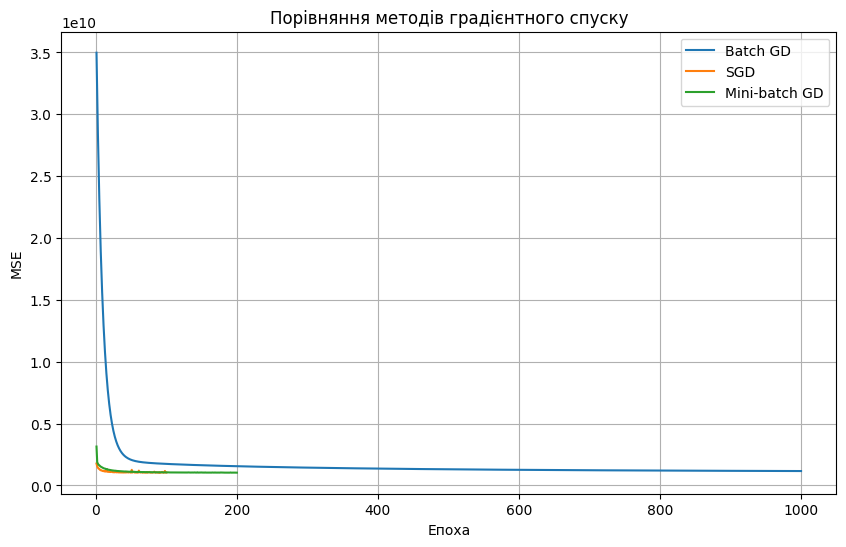

In [28]:
# Будує графік зміни MSE для трьох методів
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(batch_history) + 1),
    batch_history,
    label="Batch GD"
)

plt.plot(
    range(1, len(sgd_history) + 1),
    sgd_history,
    label="SGD"
)

plt.plot(
    range(1, len(mini_history) + 1),
    mini_history,
    label="Mini-batch GD"
)

plt.xlabel("Епоха")
plt.ylabel("MSE")
plt.title("Порівняння методів градієнтного спуску")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# Виводи останні значення MSE для аналізу стабільності
print("Останні 5 значень Batch GD:")
print(batch_history[-5:])

print("\nОстанні 5 значень SGD:")
print(sgd_history[-5:])

print("\nОстанні 5 значень Mini-batch GD:")
print(mini_history[-5:])

Останні 5 значень Batch GD:
[np.float64(1163327509.3543432), np.float64(1163168806.64727), np.float64(1163010395.5478709), np.float64(1162852275.2981627), np.float64(1162694445.1426427)]

Останні 5 значень SGD:
[np.float64(1027144765.2593732), np.float64(1044452570.3525909), np.float64(1170390969.3125277), np.float64(1039578187.3867362), np.float64(1041888364.9398607)]

Останні 5 значень Mini-batch GD:
[np.float64(1036356784.9327705), np.float64(1034450488.3919728), np.float64(1039202456.3973457), np.float64(1034141083.3329372), np.float64(1032051348.2649446)]


#### Порівняння методів градієнтного спуску

За результатами навчання всі три методи зменшують значення MSE.
**Batch GD** працює найбільш стабільно, бо для кожного оновлення використовує всю навчальну вибірку, але збігається повільніше.
**SGD** оновлює параметри після кожного окремого об'єкта, тому навчається швидко, але значення MSE більше коливаються.
**Mini-batch GD** використовує невеликі групи даних. Він швидко зменшує помилку і має менші коливання порівняно з SGD.
Розмір batch впливає на поведінку алгоритму: малий batch робить оновлення частішими, але менш стабільними, а великий — стабільнішими, але потребує більше обчислень для одного оновлення.
Learning rate визначає розмір кроку під час оновлення параметрів. Якщо він занадто малий, навчання буде повільним, а якщо занадто великий — алгоритм може не збігатися.

In [30]:
# Функція для обчислення коефіцієнта детермінації R²
def r2_score_numpy(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)

In [31]:
# Функція для виведення R² на трьох вибірках
def evaluate_model(w, b, name):
    train_pred = predict(X_train_processed, w, b)
    val_pred = predict(X_val_processed, w, b)
    test_pred = predict(X_test_processed, w, b)

    print(name)
    print("Train R²:", round(r2_score_numpy(y_train_np, train_pred), 4))
    print("Validation R²:", round(r2_score_numpy(y_val_np, val_pred), 4))
    print("Test R²:", round(r2_score_numpy(y_test_np, test_pred), 4))
    print()


evaluate_model(w_batch, b_batch, "Batch GD")
evaluate_model(w_sgd, b_sgd, "SGD")
evaluate_model(w_mini, b_mini, "Mini-batch GD")

Batch GD
Train R²: 0.8068
Validation R²: 0.8735
Test R²: 0.8079

SGD
Train R²: 0.8269
Validation R²: 0.8769
Test R²: 0.8152

Mini-batch GD
Train R²: 0.8285
Validation R²: 0.8827
Test R²: 0.8321



## 4. Оцінка моделі за допомогою R²

Коефіцієнт детермінації R² показує, яку частину зміни цільової змінної може пояснити модель.
Отримані результати:
- **Batch GD:** Train = 0.8068, Validation = 0.8735, Test = 0.8079.
- **SGD:** Train = 0.8269, Validation = 0.8769, Test = 0.8152.
- **Mini-batch GD:** Train = 0.8285, Validation = 0.8827, Test = 0.8321.
Результати на Train і Test є +- близькими, тому сильного перенавчання моделі не бачимо. У проведених запусках Mini-batch GD отримав R² = 0.8321 на Test, SGD — 0.8152, а Batch GD — 0.8079.
R² може бути від'ємним. Це можливо, якщо модель прогнозує гірше, ніж просте використання середнього значення цільової змінної.

## 5. Перевірка статистичних припущень лінійної регресії

Для аналізу використаємо залишки моделі, навченої методом Mini-batch Gradient Descent.
Залишок — це різниця між реальним та прогнозованим значенням:
$$
e = y - \hat{y}
$$
Перевіримо лінійність, нормальність залишків, гомоскедастичність та мультиколінеарність.

In [32]:
# Отримує прогнози моделі на Test
y_test_pred = predict(
    X_test_processed,
    w_mini,
    b_mini
)

# Обчислює залишки
residuals = y_test_np - y_test_pred

print("Кількість прогнозів:", len(y_test_pred))
print("Кількість залишків:", len(residuals))
print("Середнє значення залишків:", np.mean(residuals))

Кількість прогнозів: 219
Кількість залишків: 219
Середнє значення залишків: 2079.056659450065


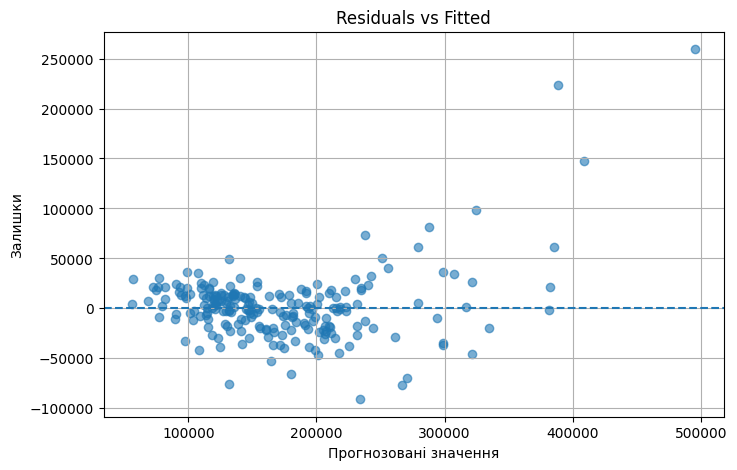

In [33]:
# Графік залишків відносно прогнозованих значень
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Прогнозовані значення")
plt.ylabel("Залишки")
plt.title("Residuals vs Fitted")
plt.grid(True)

plt.show()

#### Аналіз Residuals vs Fitted

Більшість залишків знаходяться біля нульової лінії, тому лінійна модель загалом описує залежність у даних.
При більших прогнозованих цінах розкид залишків збільшується, і видно декілька великих викидів. Тому припущення про гомоскедастичність виконується не повністю: дисперсія помилок змінюється залежно від прогнозованої ціни.

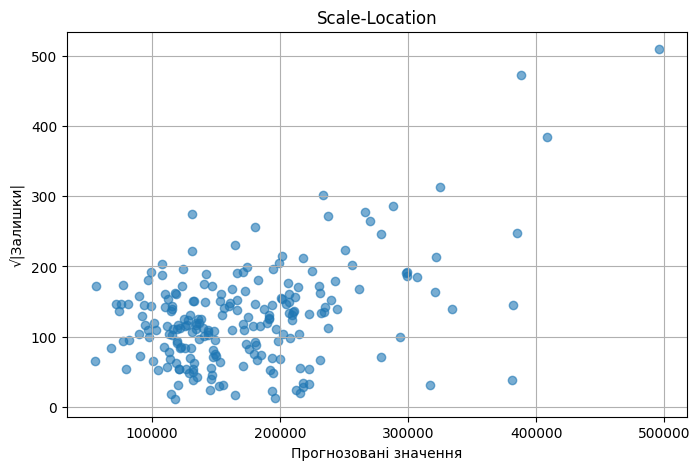

In [41]:
# Будує Scale-Location графік для перевірки гомоскедастичності
sqrt_abs_residuals = np.sqrt(np.abs(residuals))

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, sqrt_abs_residuals, alpha=0.6)

plt.xlabel("Прогнозовані значення")
plt.ylabel("√|Залишки|")
plt.title("Scale-Location")
plt.grid(True)

plt.show()

#### Аналіз Scale-Location

На графіку видно, що зі збільшенням прогнозованої ціни розкид залишків також збільшується. Тому припущення про гомоскедастичність виконується не повністю, оскільки дисперсія помилок не є однаковою для всіх прогнозованих значень.

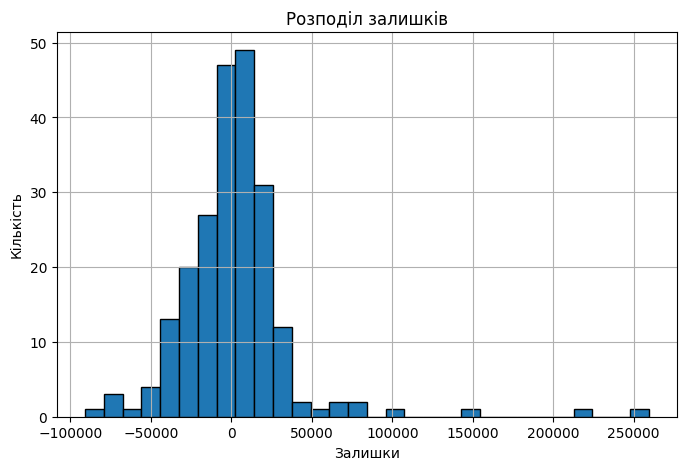

In [34]:
# Будує гістограму залишків
plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Залишки")
plt.ylabel("Кількість")
plt.title("Розподіл залишків")
plt.grid(True)

plt.show()

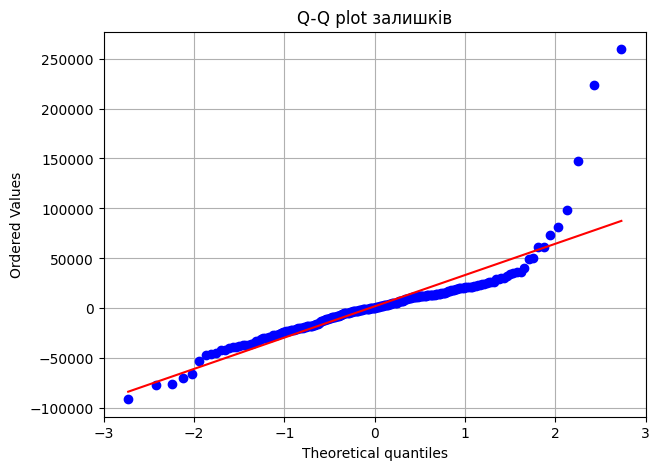

In [35]:
# Імпорт scipy для побудови Q-Q plot
from scipy import stats

plt.figure(figsize=(7, 5))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q plot залишків")
plt.grid(True)

plt.show()

In [36]:
# Перевірка нормальність залишків тестом Шапіро–Вілка
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("Статистика Шапіро–Вілка:", shapiro_stat)
print("p-value:", shapiro_p)

if shapiro_p > 0.05:
    print("Немає достатніх підстав відхиляти припущення про нормальність залишків.")
else:
    print("Є підстави вважати, що залишки не мають нормального розподілу.")

Статистика Шапіро–Вілка: 0.7644052412827751
p-value: 2.0415121730657918e-17
Є підстави вважати, що залишки не мають нормального розподілу.


#### Перевірка нормальності залишків

На Q-Q plot видно, що точки відхиляються від прямої, особливо на краях розподілу. Та тест Шапіро–Вілка показав p-value < 0.05.
Тому, залишки не мають нормального розподілу. Це може бути пов'язано з наявністю викидів та великих помилок прогнозування для деяких дорогих будинків.

In [37]:
# Перевірка мультиколінеарності вибраних числових ознак
multicollinearity_corr = X_train[final_numeric_features].corr()

multicollinearity_corr.round(2)

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,YearRemodAdd
OverallQual,1.00,0.58,0.59,0.54,0.53,0.56,0.55
GrLivArea,0.58,1.00,0.46,0.45,0.62,0.16,0.28
GarageCars,0.59,0.46,1.00,0.44,0.47,0.51,0.42
TotalBsmtSF,0.54,0.45,0.44,1.00,0.31,0.39,0.29
FullBath,0.53,0.62,0.47,0.31,1.00,0.46,0.45
YearBuilt,0.56,0.16,0.51,0.39,0.46,1.00,0.60
YearRemodAdd,0.55,0.28,0.42,0.29,0.45,0.60,1.00


#### Перевірка мультиколінеарності

Мультиколінеарність перевірено за допомогою кореляційної матриці числових ознак. Під час відбору ознак були виявлені сильні кореляції між деякими початковими ознаками, тому частину з них було вилучено. В остаточному наборі ознак немає пар із дуже високою кореляцією.
Тому, сильна мультиколінеарність між вибраними числовими ознаками не спостерігається. Мультиколінеарність може робити коефіцієнти лінійної регресії нестабільними та ускладнювати їх інтерпретацію, оскільки сильно пов'язані ознаки можуть частково дублювати одна одну.

## 6. Експеримент: вплив масштабування на градієнтний спуск

У цьому експерименті порівняємо роботу Mini-batch Gradient Descent на числових ознаках без масштабування та після стандартизації.
Мета експерименту — перевірити, як різний масштаб ознак впливає на швидкість і стабільність збіжності градієнтного спуску.

In [38]:
# Дані без масштабування
X_train_unscaled = X_train[final_numeric_features].to_numpy(dtype=float)

# Дані після стандартизації
X_train_scaled = X_train_numeric

print("Без масштабування:", X_train_unscaled.shape)
print("З масштабуванням:", X_train_scaled.shape)

Без масштабування: (1022, 7)
З масштабуванням: (1022, 7)


In [39]:
# Mini-batch GD на даних без масштабування
w_unscaled, b_unscaled, history_unscaled = mini_batch_gradient_descent(
    X_train_unscaled,
    y_train_np,
    learning_rate=0.00000001,
    epochs=200,
    batch_size=32
)

# Mini-batch GD на стандартизованих даних
w_scaled, b_scaled, history_scaled = mini_batch_gradient_descent(
    X_train_scaled,
    y_train_np,
    learning_rate=0.01,
    epochs=200,
    batch_size=32
)

print("MSE без масштабування:", history_unscaled[-1])
print("MSE з масштабуванням:", history_scaled[-1])

MSE без масштабування: 2589744248.66309
MSE з масштабуванням: 1477633339.3620148


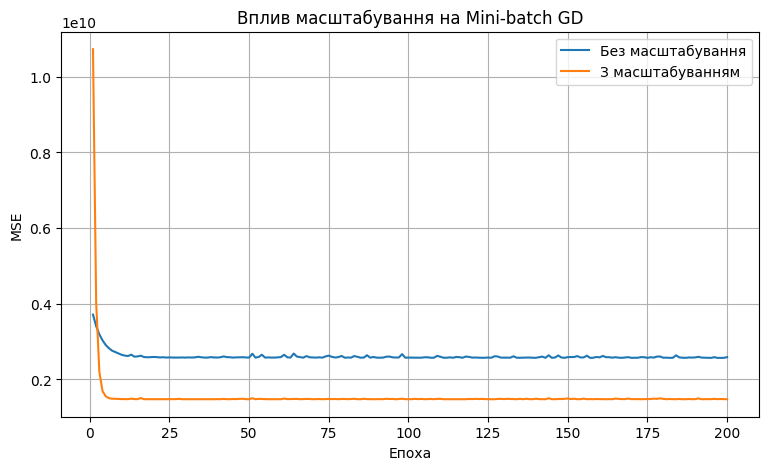

In [40]:
# Порівнює збіжність Mini-batch GD
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(history_unscaled) + 1),
    history_unscaled,
    label="Без масштабування"
)

plt.plot(
    range(1, len(history_scaled) + 1),
    history_scaled,
    label="З масштабуванням"
)

plt.xlabel("Епоха")
plt.ylabel("MSE")
plt.title("Вплив масштабування на Mini-batch GD")
plt.legend()
plt.grid(True)

plt.show()

#### Висновок експерименту

Масштабування ознак суттєво вплинуло на роботу Mini-batch Gradient Descent. Без масштабування при learning rate = 0.00000001 кінцевий MSE становив приблизно 2,59 млрд, а після стандартизації при learning rate = 0.01 — приблизно 1,48 млрд.
Це показує, що без масштабування градієнтний спуск потребує меншого кроку навчання і збігається повільніше. Геометрично через різні масштаби ознак поверхня функції втрат стає більш витягнутою, тому рух до мінімуму може бути зигзагоподібним. Після стандартизації ознаки мають близькі масштаби, тому градієнтний спуск працює швидше та стабільніше.
Отже, масштабування ознак покращило збіжність Mini-batch Gradient Descent.

##  висновок

Проведений аналіз Ames Housing Dataset і підготовлені дані для прогнозування ціни будинків `SalePrice`. Дані було розділено на Train, Validation і Test до попередньої обробки, щоб уникнути Data Leakage. Було відібрано числові та категоріальні ознаки, виконано стандартизацію та One-Hot Encoding. Лінійну регресію та обчислення MSE і градієнтів було реалізовано самостійно за допомогою NumPy. Для навчання реалізовано Batch GD, SGD та Mini-batch GD. На тестовій вибірці отримано R²: 0.8079 для Batch GD, 0.8152 для SGD та 0.8321 для Mini-batch GD. Під час статистичного аналізу було виявлено, що залишки не мають нормального розподілу, а гомоскедастичність виконується не повністю. Сильної мультиколінеарності між остаточно вибраними числовими ознаками не виявлено.
Експеримент із масштабуванням показав, що стандартизація ознак значно покращує збіжність градієнтного спуску та дозволяє використовувати більший learning rate.